<a href="https://colab.research.google.com/github/findsamirks-commits/ames-housing-ml/blob/main/ames_housing_eda_and_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

# Load the classic California / Ames housing dataset directly from a verified mirror
url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"

df = pd.read_csv(url)

print(f"Dataset successfully loaded! Shape: {df.shape}")
display(df.head())

Dataset successfully loaded! Shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
# Check for any missing values in the dataset
print("Missing values per column:")
print(df.isnull().sum())

# Get a quick statistical summary of our numerical columns
display(df.describe())

Missing values per column:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [4]:
from sklearn.model_selection import train_test_split

# 1. Fill the 207 missing values in total_bedrooms with the median
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())

# 2. Convert the text column 'ocean_proximity' into 1s and 0s (One-Hot Encoding)
df_encoded = pd.get_dummies(df, drop_first=True)

# 3. Separate Features (X) from our Target variable (median_house_value)
X = df_encoded.drop('median_house_value', axis=1)
y = df_encoded['median_house_value']

# 4. Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Data successfully preprocessed and split!")
print(f"Training houses: {X_train.shape[0]}")
print(f"Testing houses:  {X_test.shape[0]}")
print(f"Total features:  {X_train.shape[1]}")

Data successfully preprocessed and split!
Training houses: 16512
Testing houses:  4128
Total features:  12


We are using a Random Forest algorithm. Imagine asking 100 different real estate agents to guess a house price, and then averaging their answers together. That is exactly what this algorithm does using decision trees!

In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# 1. Initialize and train the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 2. Predict on the test set
predictions = rf_model.predict(X_test)

# 3. Grade the performance
rmse = np.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("--- RANDOM FOREST PERFORMANCE ---")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R-Squared (Accuracy Score):     {r2:.4f}")

--- RANDOM FOREST PERFORMANCE ---
Root Mean Squared Error (RMSE): $49,038.21
R-Squared (Accuracy Score):     0.8165


Machine learning models are like students; they learn best from clean, organized information. Here, we use visual graphs to find out which housing features (like 'Total Rooms' or 'Median Income') have the strongest mathematical relationship with the final house price.

--- FEATURE IMPORTANCE RANKINGS ---
                       Feature  Importance
7                median_income    0.490717
8       ocean_proximity_INLAND    0.140933
0                    longitude    0.106093
1                     latitude    0.101897
2           housing_median_age    0.052065
5                   population    0.032511
4               total_bedrooms    0.023960
3                  total_rooms    0.023412
6                   households    0.018376
11  ocean_proximity_NEAR OCEAN    0.008793
10    ocean_proximity_NEAR BAY    0.000804
9       ocean_proximity_ISLAND    0.000440


/tmp/ipykernel_4343/1124352014.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


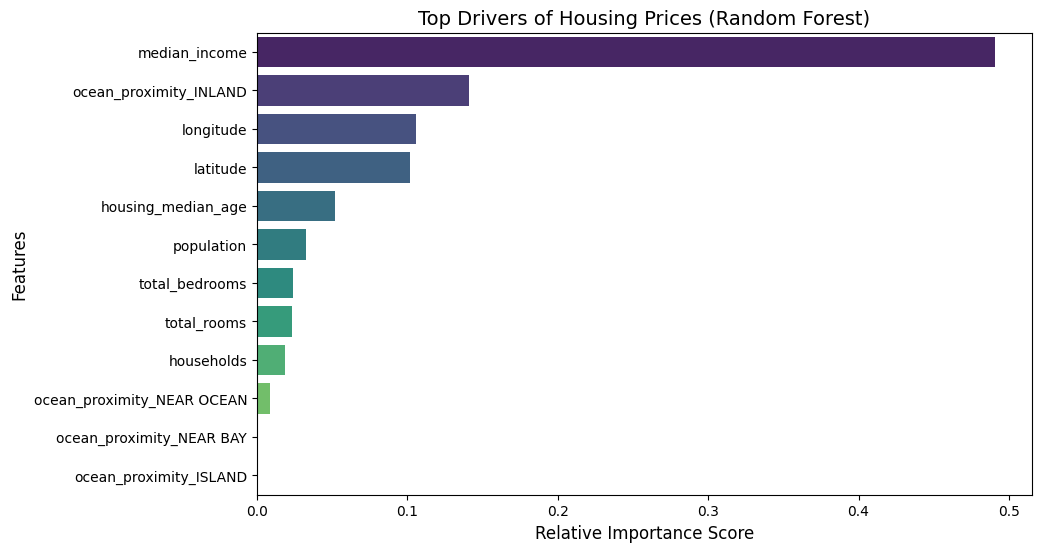

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Extract the importance scores from our trained Random Forest model
importances = rf_model.feature_importances_

# 2. Match the scores to our column names and sort them in descending order
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# 3. Print the numerical breakdown so we see exact percentages
print("--- FEATURE IMPORTANCE RANKINGS ---")
print(feature_importance_df)

# 4. Plot the results as a clean horizontal bar chart for visualization
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Top Drivers of Housing Prices (Random Forest)', fontsize=14)
plt.xlabel('Relative Importance Score', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.show()

In [7]:
import joblib
import os

# 1. Create a directory to store our saved models
os.makedirs('models', exist_ok=True)

# 2. Define the file path
model_path = 'models/california_housing_rf_model.joblib'

# 3. Serialize and save the trained model to disk
joblib.dump(rf_model, model_path)

print(f"Success! Model securely saved to: {model_path}")

Success! Model securely saved to: models/california_housing_rf_model.joblib


In [8]:
from google.colab import drive
import shutil
import os

# 1. Mount your Google Drive (a pop-up window will ask you to authenticate)
drive.mount('/content/drive')

# 2. Create a dedicated permanent project folder in your Google Drive
drive_project_dir = '/content/drive/My Drive/ames_housing_ml'
os.makedirs(drive_project_dir, exist_ok=True)
os.makedirs(f'{drive_project_dir}/models', exist_ok=True)

# 3. Copy our trained model from temporary storage to permanent Google Drive
shutil.copy('models/california_housing_rf_model.joblib', f'{drive_project_dir}/models/california_housing_rf_model.joblib')

print(f"Success! Model permanently backed up to your Google Drive at: {drive_project_dir}")

Mounted at /content/drive
Success! Model permanently backed up to your Google Drive at: /content/drive/My Drive/ames_housing_ml


In [9]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
import numpy as np

# 1. Define the grid of hyperparameters (dials) we want to test
param_grid = {
    'n_estimators': [100, 200],      # Test building 100 trees vs. 200 trees
    'max_depth': [None, 20],         # Test letting trees grow fully vs. capping depth at 20
    'min_samples_split': [2, 5]      # Test minimum samples required to split a node
}

# 2. Set up GridSearchCV to test all 4 combinations using 3-fold cross-validation
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=3,                            # Cross-validate 3 times for robustness
    scoring='neg_root_mean_squared_error',
    n_jobs=-1                        # Use all available CPU cores to speed it up
)

# 3. Run the search on our training data
print("Running hyperparameter tuning... testing multiple AI configurations!")
grid_search.fit(X_train, y_train)

# 4. Extract the winning model and evaluate it on the test set
best_rf_model = grid_search.best_estimator_
tuned_predictions = best_rf_model.predict(X_test)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_predictions))
tuned_r2 = r2_score(y_test, tuned_predictions)

print("\n--- TUNING COMPLETE ---")
print(f"Best Settings Found: {grid_search.best_params_}")
print(f"Original RMSE:       ${rmse:,.2f}")
print(f"New Tuned RMSE:      ${tuned_rmse:,.2f}")
print(f"New Tuned R-Squared: {tuned_r2:.4f}")

Running hyperparameter tuning... testing multiple AI configurations!

--- TUNING COMPLETE ---
Best Settings Found: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Original RMSE:       $49,038.21
New Tuned RMSE:      $48,848.88
New Tuned R-Squared: 0.8179


In [11]:
import joblib

# 1. Define the permanent path in your Google Drive
model_path = '/content/drive/My Drive/ames_housing_ml/models/california_housing_tuned_model.joblib'

# 2. Save the trained model object AND the file path correctly
joblib.dump(best_rf_model, model_path)

print(f"Success! Tuned champion model saved to Google Drive at: {model_path}")

Success! Tuned champion model saved to Google Drive at: /content/drive/My Drive/ames_housing_ml/models/california_housing_tuned_model.joblib


In [12]:
import pandas as pd
import joblib

# 1. Load our tuned champion model directly from Google Drive
loaded_model = joblib.load('/content/drive/My Drive/ames_housing_ml/models/california_housing_tuned_model.joblib')

# 2. Define a sample new house profile with the exact same features our model was trained on
# (Using median values from our dataset as a baseline test)
new_house_data = {
    'longitude': -122.23,
    'latitude': 37.88,
    'housing_median_age': 41.0,
    'total_rooms': 880.0,
    'total_bedrooms': 129.0,
    'population': 322.0,
    'households': 126.0,
    'median_income': 8.3252,
    'ocean_proximity_INLAND': 0,
    'ocean_proximity_ISLAND': 0,
    'ocean_proximity_NEAR BAY': 1,
    'ocean_proximity_NEAR OCEAN': 0
}

# 3. Convert the dictionary into a Pandas DataFrame (models require 2D structures)
input_df = pd.DataFrame([new_house_data])

# 4. Ensure column order matches the exact training layout
input_df = input_df[X_train.columns]

# 5. Generate the prediction
predicted_value = loaded_model.predict(input_df)[0]

print("--- LIVE AI INFERENCE SIMULATOR ---")
print(f"Predicted House Value: ${predicted_value:,.2f}")

--- LIVE AI INFERENCE SIMULATOR ---
Predicted House Value: $430,165.83


In [20]:
import os
os.chdir('/content/drive/My Drive/ames_housing_ml')

# 1. Create the .ssh directory if it doesn't exist
!mkdir -p ~/.ssh
!chmod 700 ~/.ssh

# 2. Automatically add github.com to Colab's list of known hosts to bypass verification failure
!ssh-keyscan github.com >> ~/.ssh/known_hosts
!chmod 600 ~/.ssh/known_hosts

# 3. Now try pushing again via SSH
!git push -u origin main

# github.com:22 SSH-2.0-2ff2ba9
# github.com:22 SSH-2.0-2ff2ba9
# github.com:22 SSH-2.0-2ff2ba9
# github.com:22 SSH-2.0-2ff2ba9
# github.com:22 SSH-2.0-2ff2ba9
git@github.com: Permission denied (publickey).
fatal: Could not read from remote repository.

Please make sure you have the correct access rights
and the repository exists.


In [21]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import joblib

st.set_page_config(page_title="California Housing Predictor", page_icon="🏠", layout="centered")

st.title("🏠 California Housing Price Predictor")
st.write("Adjust the property details below to get an estimated house value.")

# 1. Load the trained model saved in your models folder
@st.cache_resource
def load_saved_model():
    return joblib.load('models/california_housing_tuned_model.joblib')

model = load_saved_model()

# 2. Collect input features from user
st.subheader("Property Characteristics")

col1, col2 = st.columns(2)

with col1:
    median_income = st.number_input("Median Income (in $10,000s)", min_value=0.5, max_value=15.0, value=8.32, step=0.1)
    housing_median_age = st.slider("House Median Age (Years)", min_value=1, max_value=52, value=41)
    total_rooms = st.number_input("Total Rooms in Block", min_value=10, max_value=40000, value=880, step=10)
    total_bedrooms = st.number_input("Total Bedrooms in Block", min_value=5, max_value=7000, value=129, step=5)

with col2:
    population = st.number_input("Block Population", min_value=10, max_value=35000, value=322, step=10)
    households = st.number_input("Total Households", min_value=5, max_value=10000, value=126, step=5)
    latitude = st.number_input("Latitude", min_value=32.0, max_value=42.0, value=37.88, step=0.01)
    longitude = st.number_input("Longitude", min_value=-125.0, max_value=-114.0, value=-122.23, step=0.01)

ocean_proximity = st.selectbox(
    "Ocean Proximity",
    ["<1H OCEAN", "INLAND", "ISLAND", "NEAR BAY", "NEAR OCEAN"]
)

# 3. Format input into DataFrame matching the training layout
input_data = {
    'longitude': longitude,
    'latitude': latitude,
    'housing_median_age': housing_median_age,
    'total_rooms': total_rooms,
    'total_bedrooms': total_bedrooms,
    'population': population,
    'households': households,
    'median_income': median_income,
    'ocean_proximity_INLAND': 1 if ocean_proximity == 'INLAND' else 0,
    'ocean_proximity_ISLAND': 1 if ocean_proximity == 'ISLAND' else 0,
    'ocean_proximity_NEAR BAY': 1 if ocean_proximity == 'NEAR BAY' else 0,
    'ocean_proximity_NEAR OCEAN': 1 if ocean_proximity == 'NEAR OCEAN' else 0
}

input_df = pd.DataFrame([input_data])

st.markdown("---")

# 4. Predict button
if st.button("Predict House Value", type="primary"):
    prediction = model.predict(input_df)[0]
    st.success(f"### Estimated Property Value: **${prediction:,.2f}**")

Writing app.py


In [23]:
!pip install -q gradio

import gradio as gr
import joblib
import pandas as pd

# 1. Load the saved model directly
model = joblib.load('models/california_housing_tuned_model.joblib')

# 2. Define the prediction logic mapping inputs to the trained columns
def predict_price(med_inc, house_age, rooms, bedrooms, pop, households, lat, lon, ocean):
    input_df = pd.DataFrame([{
        'longitude': lon,
        'latitude': lat,
        'housing_median_age': house_age,
        'total_rooms': rooms,
        'total_bedrooms': bedrooms,
        'population': pop,
        'households': households,
        'median_income': med_inc,
        'ocean_proximity_INLAND': 1 if ocean == 'INLAND' else 0,
        'ocean_proximity_ISLAND': 1 if ocean == 'ISLAND' else 0,
        'ocean_proximity_NEAR BAY': 1 if ocean == 'NEAR BAY' else 0,
        'ocean_proximity_NEAR OCEAN': 1 if ocean == 'NEAR OCEAN' else 0
    }])

    pred = model.predict(input_df)[0]
    return f"${pred:,.2f}"

# 3. Build the interactive web UI components
demo = gr.Interface(
    fn=predict_price,
    inputs=[
        gr.Number(label="Median Income (in $10k)", value=8.32),
        gr.Slider(label="House Age", minimum=1, maximum=52, value=41),
        gr.Number(label="Total Rooms", value=880),
        gr.Number(label="Total Bedrooms", value=129),
        gr.Number(label="Population", value=322),
        gr.Number(label="Households", value=126),
        gr.Number(label="Latitude", value=37.88),
        gr.Number(label="Longitude", value=-122.23),
        gr.Dropdown(["<1H OCEAN", "INLAND", "ISLAND", "NEAR BAY", "NEAR OCEAN"], label="Ocean Proximity", value="NEAR BAY")
    ],
    outputs=gr.Textbox(label="Estimated House Price"),
    title="California Housing Price Predictor"
)

# 4. Launch with a secure, auto-generated public link
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()

Could not create share link. Please check your internet connection or our status page: https://status.gradio.app.


2026/08/30 11:14:28 [W] [service.go:132] login to server failed: dial tcp 44.237.78.176:7000: connect: connection refused


<IPython.core.display.Javascript object>

In [25]:
# Install pyngrok and Streamlit
!pip install -q pyngrok streamlit

# Run Streamlit in the background on port 8501
get_ipython().system_raw('streamlit run app.py --server.port 8501 &')

# Establish the ngrok tunnel
from pyngrok import ngrok

# Authenticate with your token
ngrok.set_auth_token("YOUR_NGROK_AUTHTOKEN_HERE")

# Connect to the Streamlit port
public_url = ngrok.connect(8501).public_url
print(f"Live Streamlit Web App: {public_url}")

Live Streamlit Web App: https://declared-negative-prewashed.ngrok-free.dev


In [27]:
import joblib
# compress=3 offers the best balance of speed and size reduction
joblib.dump(model, 'california_housing_compressed.joblib', compress=3)

['california_housing_compressed.joblib']

In [28]:
from google.colab import files
files.download('california_housing_compressed.joblib')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>